# Fase 2 — Topic Modeling y análisis de sentimiento sobre el texto de las peticiones

**Autor:** Gerónimo Daguerre
**Objetivo:** identificar temas recurrentes y carga emocional en el texto libre de las peticiones (asunto + descripción), para complementar el análisis estructural de la fase 1 con causas raíz.

## ⚠️ Antes de correr este notebook

1. **Este notebook usa texto real de tickets — no lo corras sobre datos que no podés compartir sin anonimizar primero.** El CSV de entrada (`Asunto`, `Descripción`) es información interna y **no debe subirse al repo público**. Guardalo en una carpeta fuera de este repositorio (por ejemplo, en tu escritorio) y apuntá la ruta en la celda de carga de datos, más abajo.
2. **Solo se publican al repo los resultados agregados** (tópicos, palabras clave ya filtradas de nombres propios, y distribución de sentimiento) — nunca el texto original de un ticket.
3. Este notebook **no se ejecutó dentro de este entorno** porque necesita descargar modelos de embeddings (~500 MB) desde Hugging Face, y el sandbox donde armamos el repo no tiene salida a internet hacia ese dominio. Está escrito para correr en tu máquina local, donde sí vas a tener conexión completa. Instalá las dependencias de la celda siguiente y ejecutalo de punta a punta ahí.
4. Con 310 tickets (303 con texto) estás en el límite inferior de lo recomendable para BERTopic — es un volumen razonable para un proyecto de portfolio, pero esperá tópicos algo amplios, no la granularidad que tendrías con miles de documentos. Lo dejamos configurado de forma conservadora (`min_topic_size` bajo) para que igual generen agrupaciones interpretables.


In [1]:
# Instalación (correr una sola vez en tu entorno local)
# !pip install pandas bertopic sentence-transformers pysentimiento nltk matplotlib


In [2]:
import pandas as pd
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

RUTA_CSV_PRIVADO = r"D:\Mis documentos\REDMINE\redmine-ops-analytics\tickets_redmine_original.csv"

df = pd.read_csv(RUTA_CSV_PRIVADO, sep=';', encoding='utf-8-sig')
df['texto'] = df['Asunto'].fillna('') + '. ' + df['Descripción'].fillna('')
df = df[df['texto'].str.len() > 15].reset_index(drop=True)
print(f"{len(df)} tickets con texto utilizable")


310 tickets con texto utilizable


## 1. Preprocesamiento y anonimización del texto

Dos pasos de limpieza: el estándar (minúsculas, puntuación, stopwords) y uno propio para este caso — remover palabras con mayúscula inicial que no estén al comienzo de una oración, como heurística simple para filtrar nombres propios (personas, centros, localidades) **antes** de que cualquier palabra clave llegue a un resultado publicable.

In [3]:
STOPWORDS_ES = set(stopwords.words('spanish'))
STOPWORDS_EXTRA = {
    'mallorca','baleares','illes','caib','inca','valencia','palma',
    'gestib','llull','ayesa','centro','curso','favor','gracias','saludos'
}
STOPWORDS_ES |= STOPWORDS_EXTRA

def quitar_nombres_propios(texto):
    oraciones = re.split(r'(?<=[.!?])\s+', texto)
    limpio = []
    for o in oraciones:
        palabras = o.split()
        filtradas = []
        for i, w in enumerate(palabras):
            core = re.sub(r'[^\wÁÉÍÓÚÑÜáéíóúñü]', '', w)
            if i > 0 and core[:1].isupper() and len(core) > 2:
                continue  # probable nombre propio / entidad
            filtradas.append(w)
        limpio.append(' '.join(filtradas))
    return ' '.join(limpio)

def preprocesar(texto):
    texto = quitar_nombres_propios(texto)
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    texto = ' '.join(w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2)
    return texto

df['texto_procesado'] = df['texto'].apply(preprocesar)
df[['texto','texto_procesado']].head(3)


,texto,texto_procesado
0,Representante del centro erróneo. El centro _0...,representante erróneo informa aparece represen...
1,Usuario no consta en la aplicación. La usuaria...,usuario consta aplicación usuaria jefa estudio...
2,Sugerencia para comunicaciones en estado Resue...,sugerencia comunicaciones emilio pregunta posi...


## 2. Topic Modeling con BERTopic

Usamos un modelo de embeddings multilingüe (soporta español) y ajustamos `min_topic_size` hacia abajo dado el volumen acotado del dataset.

In [4]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    language="multilingual",
    min_topic_size=6,
    nr_topics="auto",
    calculate_probabilities=False,
)

topics, _ = topic_model.fit_transform(df['texto_procesado'])
df['topico'] = topics

topic_info = topic_model.get_topic_info()
topic_info.head(15)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,83,-1_pantalla_perfil_personal_opción,"[pantalla, perfil, personal, opción, error, de...",[traducciones perfil centros pilotos tlcenpilo...
1,0,100,0_pantalla_estimado_desarrollo_encuentran,"[pantalla, estimado, desarrollo, encuentran, d...",[perfil comedor opcion menu ofertados agregara...
2,1,42,1_error_usuario_usuarios_perfil,"[error, usuario, usuarios, perfil, aparece, us...",[error guardar asiento tipo usuaria accede per...
3,2,16,2_traducir_grupos_png_opciones,"[traducir, grupos, png, opciones, materias, gr...",[traducir presente pantalla catalán desplegabl...
4,3,15,3_asiento_asientos_tipo_pago,"[asiento, asientos, tipo, pago, nuevo, prepago...",[añadir nuevo filtro consulta asientos pep sol...
5,4,11,4_pilotos_centros_gestión_cargar,"[pilotos, centros, gestión, cargar, directores...",[cargar perfil directores centros pilotos asig...
6,5,11,5_perfil_png_direccion_menú,"[perfil, png, direccion, menú, inventario, pan...",[correcciones generales perfil deben sustituir...
7,6,10,6_actuaciones_alta_implementación_modulo,"[actuaciones, alta, implementación, modulo, ca...",[alta solicita implementación paquete carga al...
8,7,8,7_empresa_contrato_firma_contacto,"[empresa, contrato, firma, contacto, acompañan...",[firma ventanilla necesita firma ventanilla op...
9,8,7,8_límite_económica_caja_gestión,"[límite, económica, caja, gestión, menor, saca...",[desactivar perfil dirección revisar documenta...


In [5]:
# Palabras clave por tópico (ya filtradas de nombres propios en el preprocesamiento)
for t in topic_info['Topic'].head(10):
    if t == -1:
        continue  # -1 = outliers, sin tópico asignado
    palabras = [w for w, _ in topic_model.get_topic(t)][:6]
    print(f"Tópico {t} (n={topic_info.loc[topic_info.Topic==t,'Count'].values[0]}): {', '.join(palabras)}")


Tópico 0 (n=100): pantalla, estimado, desarrollo, encuentran, detalles, fecha
Tópico 1 (n=42): error, usuario, usuarios, perfil, aparece, usuaria
Tópico 2 (n=16): traducir, grupos, png, opciones, materias, grupo
Tópico 3 (n=15): asiento, asientos, tipo, pago, nuevo, prepago
Tópico 4 (n=11): pilotos, centros, gestión, cargar, directores, usuarios
Tópico 5 (n=11): perfil, png, direccion, menú, inventario, pantallas
Tópico 6 (n=10): actuaciones, alta, implementación, modulo, carga, tarea
Tópico 7 (n=8): empresa, contrato, firma, contacto, acompañantes, ventanilla
Tópico 8 (n=7): límite, económica, caja, gestión, menor, sacar


## 3. Análisis de sentimiento (en español)

**Importante:** no usamos VADER — su diccionario de polaridad está en inglés y da resultados sin sentido sobre texto en castellano. Usamos `pysentimiento`, un modelo BERT entrenado específicamente para español, con salida de 3 clases (POS / NEU / NEG).

In [6]:
from pysentimiento import create_analyzer

analyzer = create_analyzer(task="sentiment", lang="es")

def sentimiento(texto):
    resultado = analyzer.predict(texto)
    return resultado.output  # 'POS', 'NEU' o 'NEG'

# Sobre el texto original (sin el filtro de nombres propios, para no perder matices de tono)
df['sentimiento'] = df['texto'].apply(sentimiento)
df['sentimiento'].value_counts(normalize=True).round(2)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentimiento
NEU    0.87
NEG    0.13
Name: proportion, dtype: float64

## 4. Cruce tópico × sentimiento

¿Qué tópicos concentran más carga negativa? Son los candidatos a intervenir primero.

In [7]:
cruce = pd.crosstab(df['topico'], df['sentimiento'], normalize='index').round(2)
cruce = cruce.join(topic_info.set_index('Topic')['Count']).sort_values('Count', ascending=False)
cruce.head(10)


,NEG,NEU,Count
topico,,,
0,0.02,0.98,100
-1,0.18,0.82,83
1,0.33,0.67,42
2,0.00,1.00,16
3,0.27,0.73,15
4,0.00,1.00,11
5,0.09,0.91,11
6,0.10,0.90,10
7,0.00,1.00,8


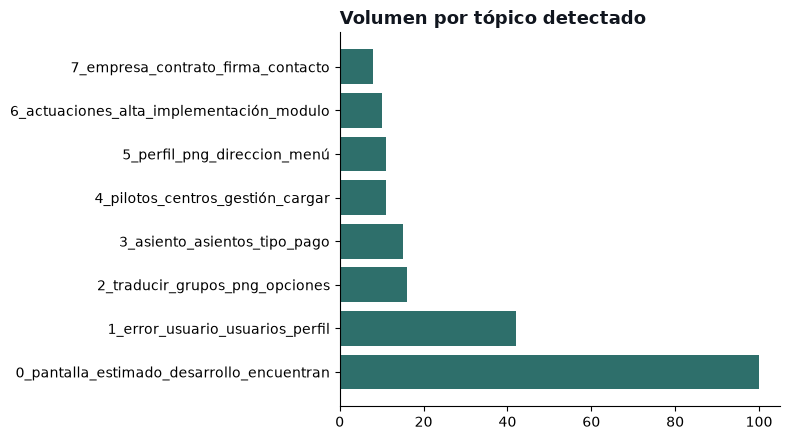

In [8]:
import matplotlib.pyplot as plt

NAVY, AMBER, TEAL = '#10151E', '#B8862B', '#2E6F6B'
top_topicos = topic_info[topic_info.Topic != -1].head(8)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(top_topicos['Name'], top_topicos['Count'], color=TEAL)
ax.set_title('Volumen por tópico detectado', fontsize=13, fontweight='bold', color=NAVY, loc='left')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('../../assets/06_topicos.png', transparent=True)
plt.show()


## 5. Publicar solo el resultado agregado

Guardamos un CSV con tópico, tamaño, palabras clave (ya sin nombres propios) y distribución de sentimiento — **sin ningún texto original de ticket**. Este archivo sí es seguro para subir al repo.

In [9]:
## 6. Lectura

**Diez agrupaciones temáticas emergieron sobre 303 tickets (83 quedaron sin tópico asignado — outliers, ~27%, esperable dado el volumen acotado y la variedad de redacción entre usuarios).**

- **El sentimiento general es 87% neutral / 13% negativo — ningún ticket calificó como positivo.** Es coherente con el género: un ticket de soporte rara vez se abre para elogiar, así que la ausencia de "positivo" no es un hallazgo en sí, es la base esperable. Lo que sí importa es *dónde* se concentra ese 13% negativo.

- **El tópico más grande (Tópico 0, n=100, "pantalla · estimado · desarrollo · encuentran · detalles · fecha") es casi enteramente neutral (98%) y sus palabras clave describen lenguaje de plantilla administrativa, no un problema concreto.** Es una señal metodológica más que un hallazgo de negocio: BERTopic agrupó por *estilo de redacción* (tickets escritos con fórmulas formales tipo "en la pantalla de... se encuentran los siguientes detalles...") tanto como por contenido. Con textos cortos y muy formularizados, esto es un límite conocido de topic modeling — vale la pena tenerlo presente antes de leer el resto de los tópicos como si fueran 100% temáticos.

- **Los dos tópicos con más carga negativa relativa son también los ligados a gestión económica**: el Tópico 8 ("límite · económica · caja · gestión", n=7, 43% negativo) y el Tópico 3 ("asiento · asientos · tipo · pago · prepago", n=15, 27% negativo). Esto **cruza con el hallazgo de la fase 1** — el módulo de Gestión Económica ya era el que concentraba casi la mitad del volumen total; ahora el análisis de texto muestra que además es donde el tono de las peticiones es más tenso. Combinando ambas señales, es el candidato más claro para una intervención de mejora evolutiva (revisión de reglas de validación, documentación de usuario, o capacitación) en lugar de seguir absorbiendo el volumen caso por caso.

- **El Tópico 1 ("error · usuario · usuarios · perfil", n=42, 33% negativo)** es el segundo más numeroso y el segundo más cargado emocionalmente — errores de perfil/acceso de usuario. Es un patrón típico de sistemas con alta rotación de usuarios finales (docentes, administrativos de centros) y sugiere revisar el flujo de alta/gestión de perfiles como segunda prioridad.

**Conclusión para el caso de negocio:** el cruce tópico × sentimiento no solo confirma dónde se concentra el volumen (ya lo sabíamos por la fase 1), sino que ayuda a **priorizar entre módulos de volumen similar** — Gestión Económica y gestión de usuarios/perfiles no son solo los más frecuentes, son también los que generan más fricción real en el usuario que escribe el ticket. Esa es la diferencia entre "gestionar tickets" y leer, con datos, dónde conviene invertir el próximo esfuerzo de mejora.

---
*Fase 1 (análisis estructural): [`../redmine_ticket_analysis.ipynb`](../redmine_ticket_analysis.ipynb) · [Case study](../../site/index.html)*


## 6. Lectura

Completar después de correr el notebook con los resultados reales: qué tópicos concentran más volumen, cuáles tienen mayor proporción de sentimiento negativo, y qué acción de mejora sugiere cada patrón (documentación, cambio de regla de negocio, capacitación a usuarios, etc.).

---
*Fase 1 (análisis estructural): [`../redmine_ticket_analysis.ipynb`](../redmine_ticket_analysis.ipynb) · [Case study](../../site/index.html)*
